In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.models import Sequential, Model, load_model
from keras.layers import Reshape, Dense, Input
from sklearn.model_selection import train_test_split
import keras_tuner as kt
from keras.utils import plot_model
import pandas as pd


In [ ]:
data_folder = "prob1_data"

output_file = data_folder + "/output.xlsx"
stress_folder = data_folder + "/stress"


In [ ]:
X_df = pd.read_excel(output_file, header=None)

# Remove completely empty rows or columns, if any
X_df = X_df.dropna(axis=0, how="all")
X_df = X_df.dropna(axis=1, how="all")

X = X_df.values.astype(float)

print("Input data shape:", X.shape)


Input data shape: (5000, 226)


In [ ]:
num_samples = X.shape[0]
print("Number of samples:", num_samples)

y = []

for i in range(num_samples):
    stress_file = stress_folder + "/stress_" + str(i) + ".txt"
    
    stress_data = np.loadtxt(stress_file)
    
    von_mises_stress = stress_data[:, 0]
    max_stress = np.max(von_mises_stress)
    
    y.append(max_stress)

y = np.array(y).reshape(-1, 1)

print("Target data shape:", y.shape)
print("Minimum max stress:", np.min(y))
print("Maximum max stress:", np.max(y))


Number of samples: 5000
Target data shape: (5000, 1)
Minimum max stress: 4412533.22285112
Maximum max stress: 43744146.8480609


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (4000, 226)
X_test shape: (1000, 226)
y_train shape: (4000, 1)
y_test shape: (1000, 1)


In [ ]:
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

y_mean = np.mean(y_train, axis=0)
y_std = np.std(y_train, axis=0)

# Avoid division by zero
X_std[X_std == 0] = 1

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std


In [ ]:
def r2metric(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())


In [ ]:
tf.keras.backend.clear_session()

model1 = Sequential()
model1.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],),
                 kernel_initializer=keras.initializers.HeNormal()))
model1.add(layers.Dropout(0.1))

model1.add(Dense(32, activation='relu',
                 kernel_initializer=keras.initializers.HeNormal()))
model1.add(layers.Dropout(0.1))

model1.add(Dense(16, activation='relu',
                 kernel_initializer=keras.initializers.HeNormal()))

model1.add(Dense(1, name='Output'))

model1.summary()



/home/sputnik/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        14,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,745 (77.13 KB)

 Trainable params: 19,745 (77.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.002),loss='mse',metrics=[r2metric, 'mape'])
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

history = model1.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=250,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9488 - mape: 347.9576 - r2metric: -0.1916 - val_loss: 0.8494 - val_mape: 236.0270 - val_r2metric: 0.1479
Epoch 2/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6439 - mape: 301.6380 - r2metric: 0.1614 - val_loss: 0.6812 - val_mape: 285.1576 - val_r2metric: 0.3370
Epoch 3/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4062 - mape: 269.9838 - r2metric: 0.4173 - val_loss: 0.5944 - val_mape: 260.8093 - val_r2metric: 0.4355
Epoch 4/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2928 - mape: 265.9870 - r2metric: 0.5286 - val_loss: 0.5726 - val_mape: 267.4633 - val_r2metric: 0.4519
Epoch 5/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2507 - mape: 199.1244 - r2metric: 0.6134 - val_loss: 0.5742 - val_mape: 245.2168 - val_r2metric: 0.4735
Epoch 6/250
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2239 - mape: 212.3173 - r2metric: 0.6580 - val_loss: 0.5061 - val_mape: 242.8123 - val_r2metric: 0.52

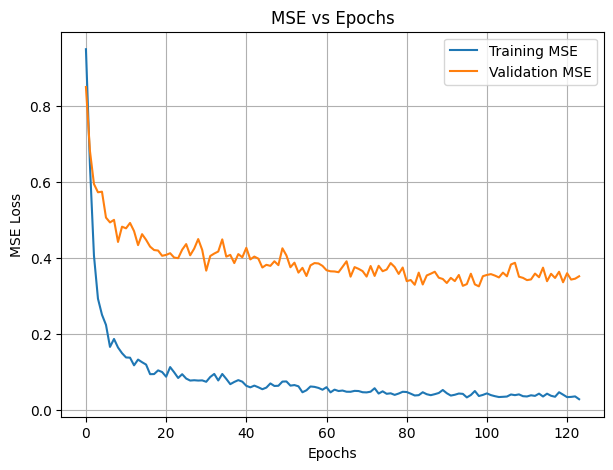

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='Training MSE')
plt.plot(history.history['val_loss'], label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('MSE vs Epochs')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
train_loss, train_r2, train_mape = model1.evaluate(X_train_scaled, y_train_scaled, verbose=0)

test_loss, test_r2, test_mape = model1.evaluate(X_test_scaled, y_test_scaled, verbose=0)

print("Training MSE:", train_loss)
print("Training R2-score:", train_r2)
print("Training MAPE:", train_mape)

print("Testing MSE:", test_loss)
print("Testing R2-score:", test_r2)
print("Testing MAPE:", test_mape)


Training MSE: 0.08167019486427307
Training R2-score: 0.9168267250061035
Training MAPE: 80.56895446777344
Testing MSE: 0.2737942039966583
Testing R2-score: 0.6538054943084717
Testing MAPE: 143.67001342773438


In [ ]:
y_train_pred_scaled = model1.predict(X_train_scaled)
y_test_pred_scaled = model1.predict(X_test_scaled)

# Convert predictions back to original stress scale
y_train_pred = y_train_pred_scaled * y_std + y_mean
y_test_pred = y_test_pred_scaled * y_std + y_mean


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
train_mse_actual = np.mean((y_train - y_train_pred)**2)
test_mse_actual = np.mean((y_test - y_test_pred)**2)


print("Training MSE in actual stress scale:", train_mse_actual)
print("Testing MSE in actual stress scale:", test_mse_actual)


mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100


ss_res = np.sum((y_test - y_test_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - (ss_res / ss_tot)

print("Testing MAPE (%):", mape)
print("Testing R2 Score:", r2)



Training MSE in actual stress scale: 1327815277357.5183
Testing MSE in actual stress scale: 4451416291119.585
Testing MAPE (%): 12.13198360675361
Testing R2 Score: 0.6652707602591678


In [ ]:
sample_number = 0

x_sample = X_test[sample_number:sample_number+1]
x_sample_scaled = X_test_scaled[sample_number:sample_number+1]

actual_stress = y_test[sample_number]

print("Sample number:", sample_number)
print("Volume fraction:", np.mean(x_sample))
print("Actual maximum Von Mises stress:", actual_stress[0])


Sample number: 0
Volume fraction: 0.0010706540865118989
Actual maximum Von Mises stress: 9774365.95093914


In [ ]:
x_tensor = tf.convert_to_tensor(x_sample_scaled, dtype=tf.float32)


In [ ]:
with tf.GradientTape() as tape:
    tape.watch(x_tensor)
    
    predicted_stress_scaled = model1(x_tensor)
    
gradient_scaled = tape.gradient(predicted_stress_scaled, x_tensor)

print("Gradient shape:", gradient_scaled.shape)


Gradient shape: (1, 226)


In [ ]:
gradient_actual = gradient_scaled.numpy() * y_std / X_std

print("Gradient in actual stress scale:")
print(gradient_actual)


Gradient in actual stress scale:
[[-8.37353042e+09  4.20587072e+08  5.77552778e+07  1.53109321e+08
  -3.97296366e+08 -8.16997660e+07 -2.32324694e+08 -1.61080395e+08
  -7.82979139e+07  3.41284286e+08 -5.25066181e+08  3.27437828e+08
  -4.48313592e+07 -9.85610241e+07  7.19017742e+07 -6.48928166e+08
  -4.10272356e+08  1.49794501e+08 -3.72612946e+07  2.27930816e+07
   6.51512492e+07 -9.65397544e+08 -5.15654324e+08 -5.58569375e+08
  -5.92274649e+08 -1.24642063e+08 -6.97607188e+07  1.02025202e+07
   1.89848978e+06 -3.13147674e+08 -1.04561907e+08  3.04995518e+07
  -1.45766789e+08  2.11439477e+08 -1.73769181e+08 -3.45732222e+08
  -1.59151789e+08 -8.70819491e+07 -1.29243626e+08 -2.75692989e+07
   3.72503123e+07 -9.57021688e+07  1.50681086e+08 -6.14711703e+08
  -6.10148540e+08 -1.74229269e+08  3.95173960e+07 -5.86713268e+07
  -2.94451606e+08 -1.46112058e+08 -2.04541222e+08 -1.29889597e+08
   8.74581116e+07  2.41686994e+08  3.29618297e+08  1.03633864e+06
   4.95227112e+07 -3.99275194e+08 -1.754918

In [ ]:
num_features = X.shape[1]
d_stress_d_vf = np.sum(gradient_actual * (1/num_features))

print("Derivative of maximum Von Mises stress with respect to volume fraction:")
print(d_stress_d_vf)


Derivative of maximum Von Mises stress with respect to volume fraction:
-54505922.681466505


In [ ]:
d_stress_d_vf_all = []

for i in range(X_test_scaled.shape[0]):
    
    x_tensor = tf.convert_to_tensor(X_test_scaled[i:i+1], dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        predicted_stress_scaled = model1(x_tensor)
    
    gradient_scaled = tape.gradient(predicted_stress_scaled, x_tensor)
    gradient_actual = gradient_scaled.numpy() * y_std / X_std
    
    d_stress_d_vf = np.sum(gradient_actual)
    d_stress_d_vf_all.append(d_stress_d_vf)

d_stress_d_vf_all = np.array(d_stress_d_vf_all)

print("Shape:", d_stress_d_vf_all.shape)
print("Mean derivative:", np.mean(d_stress_d_vf_all))
print("Minimum derivative:", np.min(d_stress_d_vf_all))
print("Maximum derivative:", np.max(d_stress_d_vf_all))


Shape: (1000,)
Mean derivative: -14613170625.779512
Minimum derivative: -66921824712.21597
Maximum derivative: 2391758439.6514473


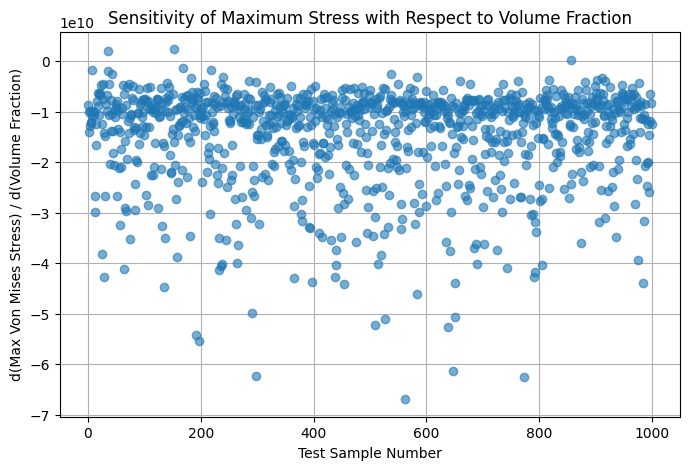

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(d_stress_d_vf_all, marker='o', linestyle='', alpha=0.6)
plt.xlabel("Test Sample Number")
plt.ylabel("d(Max Von Mises Stress) / d(Volume Fraction)")
plt.title("Sensitivity of Maximum Stress with Respect to Volume Fraction")
plt.grid(True)
plt.show()


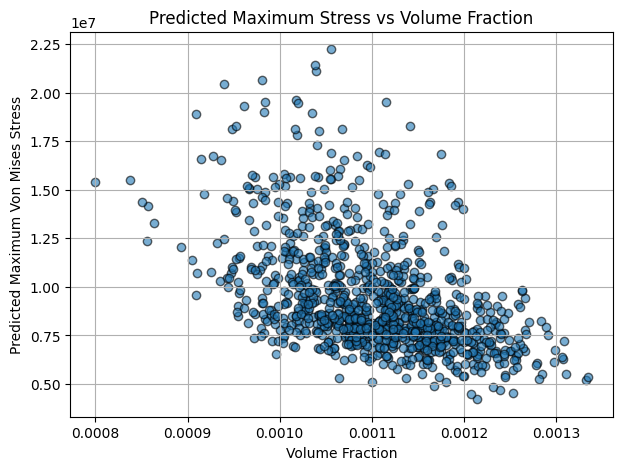

In [ ]:
volume_fraction_test = np.mean(X_test, axis=1)

y_test_pred_scaled = model1.predict(X_test_scaled, verbose=0)
y_test_pred = y_test_pred_scaled * y_std + y_mean

plt.figure(figsize=(7, 5))
plt.scatter(volume_fraction_test, y_test_pred, alpha=0.6, edgecolor="black")
plt.xlabel("Volume Fraction")
plt.ylabel("Predicted Maximum Von Mises Stress")
plt.title("Predicted Maximum Stress vs Volume Fraction")
plt.grid(True)
plt.show()


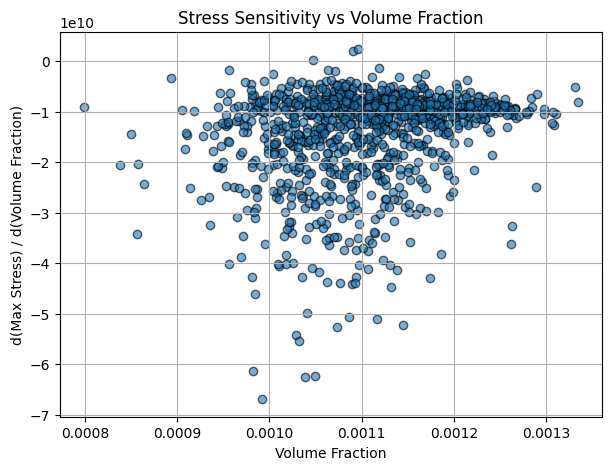

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(volume_fraction_test, d_stress_d_vf_all, alpha=0.6, edgecolor="black")
plt.xlabel("Volume Fraction")
plt.ylabel("d(Max Stress) / d(Volume Fraction)")
plt.title("Stress Sensitivity vs Volume Fraction")
plt.grid(True)
plt.show()


In [ ]:
epsilon = 0.001

x_plus = x_sample + epsilon
x_minus = x_sample - epsilon

x_plus_scaled = (x_plus - X_mean) / X_std
x_minus_scaled = (x_minus - X_mean) / X_std

stress_plus_scaled = model1.predict(x_plus_scaled, verbose=0)
stress_minus_scaled = model1.predict(x_minus_scaled, verbose=0)

stress_plus = stress_plus_scaled * y_std + y_mean
stress_minus = stress_minus_scaled * y_std + y_mean

finite_difference_derivative = (stress_plus - stress_minus) / (2 * epsilon)

print("Backpropagation derivative:", d_stress_d_vf)
print("Finite difference derivative:", finite_difference_derivative[0][0])


Backpropagation derivative: -12318338526.011433
Finite difference derivative: -13319479280.374058
